In [61]:
import numpy as np
import scipy as sp
from numpy import log, cosh, sinh, sqrt, zeros, linspace, ones, exp, argmin, pi
import matplotlib.pyplot as plt
from matplotlib.pyplot import gca
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn, factorial
from scipy.integrate import quad
import warnings
warnings.filterwarnings('ignore')
from utils import graphene_conductivity

In [2]:
Rs = np.linspace(2, 256, 255)
epsilon_F = 0.4
alpha = 1/137
epsilon_1 = epsilon_2 = 1

In [3]:
hbar_omegas = zeros((5, (len(Rs))))
for (i, l) in enumerate(range(1, 6)):
    hbar_omegas[i, :] = sqrt(l*(l+1)*alpha*800*epsilon_F/(l*epsilon_1+(l+1)*epsilon_2)/Rs)/epsilon_F; #Intraband only approximation

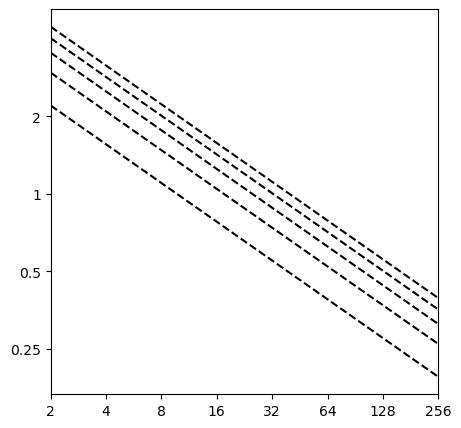

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(0, 5):
    ax.plot(log(Rs), log(hbar_omegas[i, :]), color="black", linestyle="dashed" )
plt.gca().set_xlim(log(2), log(256))
plt.gca().set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
plt.gca().set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);

## In the below, we introduce the interband contribution

In [5]:
R_range = np.linspace(2, 256, 255)
hbar_omega_range = epsilon_F * np.linspace(0.01, 2, 400)
dispersion = zeros((5, len(R_range)))

for (i, l) in enumerate(range(1, 6)):
    lhs = R_range*(epsilon_1/(l+1)+epsilon_2/l)
    rhs = (800 * alpha)/(hbar_omega_range)*(epsilon_F/hbar_omega_range+(1/4)*log(abs((2*epsilon_F-hbar_omega_range)/(2*epsilon_F+hbar_omega_range))))
    dispersion[i, :] = hbar_omega_range[np.argmin(log(abs(lhs.reshape(255, 1 ).repeat(400, 1) - rhs.reshape(1, 400).repeat(255, 0))), 1)]

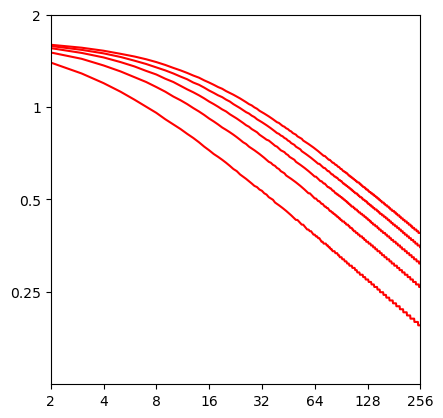

In [6]:
for i in range(0, 5): 
    plt.plot(log(R_range), log(dispersion[i, :]/epsilon_F), color="red")
gca().set_xlim(log(2), log(256))
gca().set_ylim(log(0.125), log(2))

gca().set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
gca().set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);
gca().set_aspect((log(256)-log(2))/(log(2)-log(0.125)))

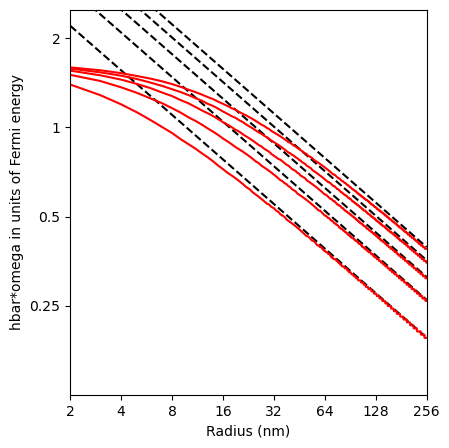

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(0, 5):
    ax.plot(log(Rs), log(hbar_omegas[i, :]), color="black", linestyle="dashed" )
    ax.plot(log(R_range), log(dispersion[i, :]/epsilon_F), color="red")
gca().set_xlim(log(2), log(256))
gca().set_ylim(log(0.125), log(2.5))

gca().set_xticks(log([2, 4, 8, 16, 32, 64, 128, 256]), [2, 4, 8, 16, 32, 64, 128, 256]);
gca().set_yticks(log([0.25, 0.5, 1, 2]), [0.25, 0.5, 1, 2]);
gca().set_aspect((log(256)-log(2))/(log(2)-log(0.125)))
gca().set_xlabel("Radius (nm)");
gca().set_ylabel("hbar*omega in units of Fermi energy");

### In the below, we find the crossover point where g(omega) changes sign. 

In [8]:
x = linspace(0.1, 1, 10000)
y = exp(4*x)-abs((2*x+1)/(2*x-1))

In [9]:
print(f"omega/fermi_energy: {1/x[argmin(abs(y))]}")

omega/fermi_energy: 1.6671668667466986


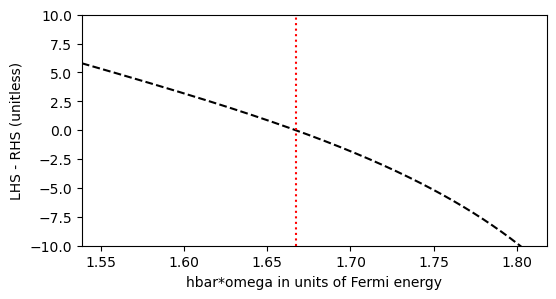

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
plt.plot(1 / x, y, color="black", linestyle="dashed")
plt.ylim(-10, 10);
plt.xlim(1/0.65, 1/0.55);
plt.xlabel("hbar*omega in units of Fermi energy")
plt.ylabel("LHS - RHS (unitless)");
plt.vlines([1/x[argmin(abs(y))]], -10, 10, linestyle="dotted", color="red");

# Below we check out the extinction cross section

In [85]:
### First, we double check the graphene conductivity
from_utils = np.array([])
finite_temperature = np.array([])
omegas = np.linspace(0.01, 1.2, 100)
for omega in np.linspace(0.01, 1.2, 100):
    omega_tilde = omega + 0.01j
    T = 0.005
    sigma_intraband = (2j*T/omega_tilde)*log(2*cosh(epsilon_F/2/T))
    sigma_interband_1 = (pi/4)*H(omega/2, epsilon_F, T) 
    sigma_interband_2 = 1j * omega_tilde * quad(lambda x: (H(x, epsilon_F, T) - H(omega, epsilon_F, T))/(omega_tilde**2-4*x**2), 0, 2, limit=100)[0]
    finite_temperature = np.append(finite_temperature, (sigma_intraband + sigma_interband_1 + sigma_interband_2)*4*alpha)
    from_utils = np.append(from_utils, graphene_conductivity(epsilon_F, omega, 0.01, True))

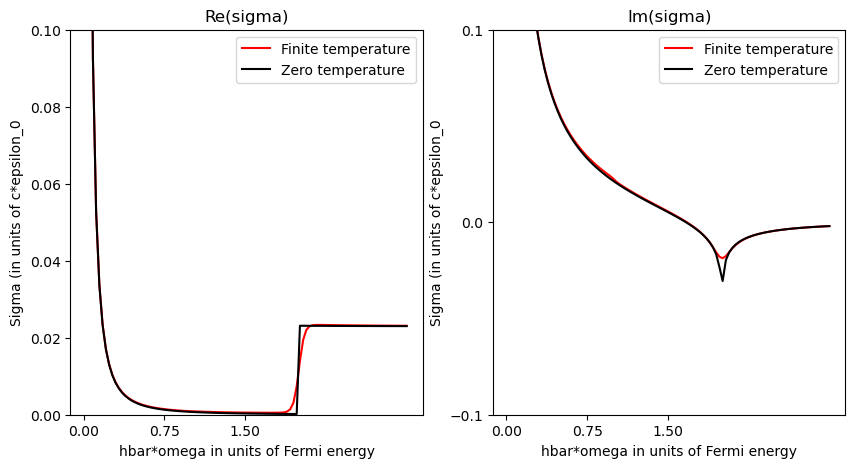

In [101]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(omegas/epsilon_F, finite_temperature.real, color="red", label="Finite temperature")
ax1.plot(omegas/epsilon_F, from_utils.real, color="black", label="Zero temperature")
ax1.set_ylim(0, 0.1)
ax1.set_xticks([0, 0.75, 1.5])
ax1.set_title("Re(sigma)")
ax1.set_ylabel("Sigma (in units of c*epsilon_0")
ax1.set_xlabel("hbar*omega in units of Fermi energy")
ax1.legend();
ax2.plot(omegas/epsilon_F, finite_temperature.imag, color="red", label="Finite temperature")
ax2.plot(omegas/epsilon_F, from_utils.imag, color="black", label="Zero temperature")
ax2.set_yticks([-0.1, 0, 0.1])
ax2.set_ylim(-0.1, 0.1);
ax2.set_xticks([0, 0.75, 1.5])
ax2.set_title("Im(sigma)")
ax2.set_ylabel("Sigma (in units of c*epsilon_0")
ax2.set_xlabel("hbar*omega in units of Fermi energy");
ax2.legend();

In [14]:
def H(omega, epsilon_F, T):
    return (sinh(omega/T))/(cosh(omega/T)+cosh(epsilon_F/T))
      
def extinction_cross_section(epsilon_1, epsilon_2, epsilon_F, omega, T, R):
    omega_tilde = omega + 0.02j 
    sigma_intraband = (2j*T/omega_tilde)*log(2*cosh(epsilon_F/2/T))
    sigma_interband_1 = (pi/4)*H(omega/2, epsilon_F, T) 
    sigma_interband_2 = 1j * omega_tilde * quad(lambda x: (H(x, epsilon_F, T) - H(omega, epsilon_F, T))/(omega_tilde**2-4*x**2), 0, 8)[0]
    g_intraband = ((800 * alpha * 1j)/(omega * R))*sigma_intraband
    g_interband = ((800 * alpha * 1j)/(omega * R))*(sigma_interband_1 + sigma_interband_2)
    g = g_intraband + g_interband
    k_2 = sqrt(epsilon_2) * omega/(200) 
    alpha_1_numerator = epsilon_1 - epsilon_2 + 2 * g
    alpha_1_denominator = epsilon_1 + 2 * epsilon_2 + 2 * g
    alpha_1 = 4*pi*(R**3)*(alpha_1_numerator/alpha_1_denominator)
    return (k_2 * (alpha_1.imag) + (abs(alpha_1)**2)*(k_2**4)/6/pi)/pi/(R**2)


In [127]:
frequencies = linspace(0.001, 1, 1000);

In [128]:
Rs = [5, 10, 20, 50, 200]
cross_sections = zeros((len(Rs), len(frequencies)))

for (R_i, R) in enumerate(Rs):
    print(f"R: {R}", flush=True)
    cross_sections[R_i, :] = list(map(lambda x: extinction_cross_section(1, 1, 0.4, x, 0.025851984449221682, R), frequencies));

R: 5
R: 10
R: 20
R: 50
R: 200


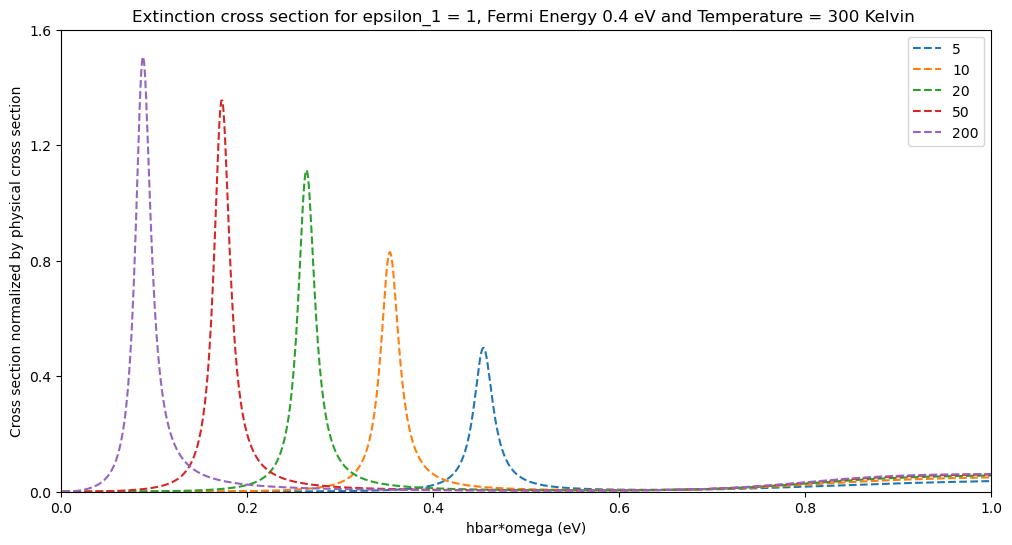

In [129]:
fig, ax = plt.subplots(figsize=(12, 6))
for R_i in range(0, 5):
    ax.plot(frequencies, cross_sections[R_i, :], linestyle="dashed", label=Rs[R_i])
ax.legend()
ax.set_ylim(0, 1.6)
ax.set_yticks([0, 0.4, 0.8, 1.2, 1.6]);
ax.set_xlim(0, 1);
ax.set_title("Extinction cross section for epsilon_1 = 1, Fermi Energy 0.4 eV and Temperature = 300 Kelvin ");
ax.set_xlabel("hbar*omega (eV)")
ax.set_ylabel("Cross section normalized by physical cross section");

In [131]:
Rs = [5, 10, 20, 50, 200]
cross_sections = zeros((len(Rs), len(frequencies)))

for (R_i, R) in enumerate(Rs):
    print(f"R: {R}", flush=True)
    cross_sections[R_i, :] = list(map(lambda x: extinction_cross_section(2.4, 1, 0.4, x, 0.025851984449221682, R), frequencies));

R: 5
R: 10
R: 20
R: 50
R: 200


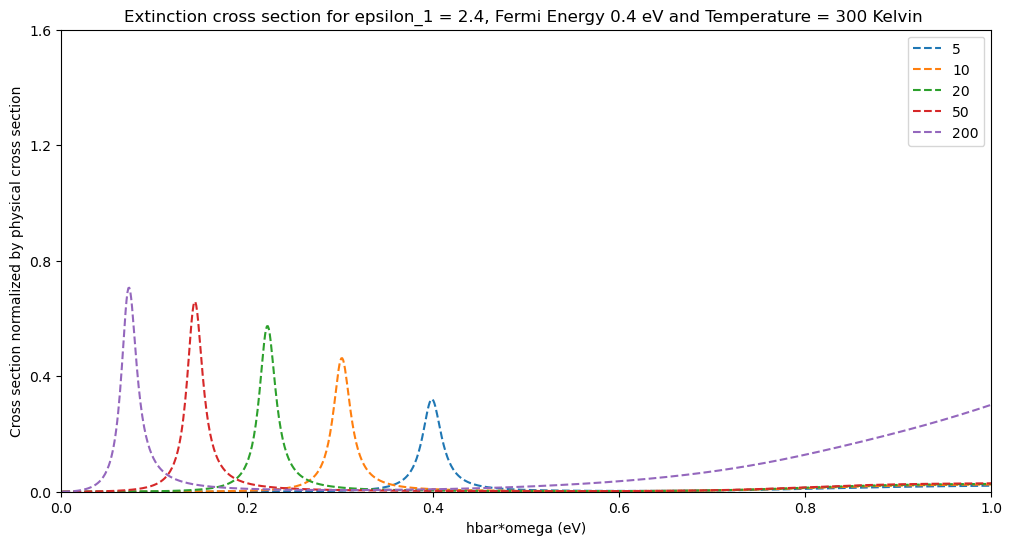

In [133]:
fig, ax = plt.subplots(figsize=(12, 6))
for R_i in range(0, 5):
    ax.plot(frequencies, cross_sections[R_i, :], linestyle="dashed", label=Rs[R_i])
ax.legend()
ax.set_yticks([0, 0.4, 0.8, 1.2, 1.6]);
ax.set_ylim(0, 1.6)

ax.set_xlim(0, 1);
ax.set_title("Extinction cross section for epsilon_1 = 2.4, Fermi Energy 0.4 eV and Temperature = 300 Kelvin ");
ax.set_xlabel("hbar*omega (eV)");
ax.set_ylabel("Cross section normalized by physical cross section");

## Below, we check that the numerical integration routines give the correct answer in the low temperature limit

In [187]:
def H_zero_T(epsilon, epsilon_F):
    return np.heaviside(epsilon - epsilon_F, 0.5)

In [222]:
omegas = linspace(0.001, 1, 1000)
upper_limits = [4, 8, 12, 16, 20]
sigmas = zeros((len(upper_limits), len(omegas)))
warnings.filterwarnings('ignore')
epsilon_F = 0.4 

for (n, upper_limit) in enumerate(upper_limits):
    print(f"Evaluating conductivity with upper limit: {upper_limit}")
    for (m, omega) in enumerate(omegas):
        omega_tilde = omega + 0.0005j
        sigmas[n, m] = (1j * omega_tilde * quad(lambda x: (H_zero_T(x, epsilon_F) - H_zero_T(omega, epsilon_F))/(omega_tilde**2-4*x**2), 0, upper_limit)[0]).imag


Evaluating conductivity with upper limit: 4
Evaluating conductivity with upper limit: 8
Evaluating conductivity with upper limit: 12
Evaluating conductivity with upper limit: 16
Evaluating conductivity with upper limit: 20


In [223]:
sigmas_analytic = (1/4)*log(abs((2*epsilon_F-omegas)/(2*epsilon_F+omegas)))

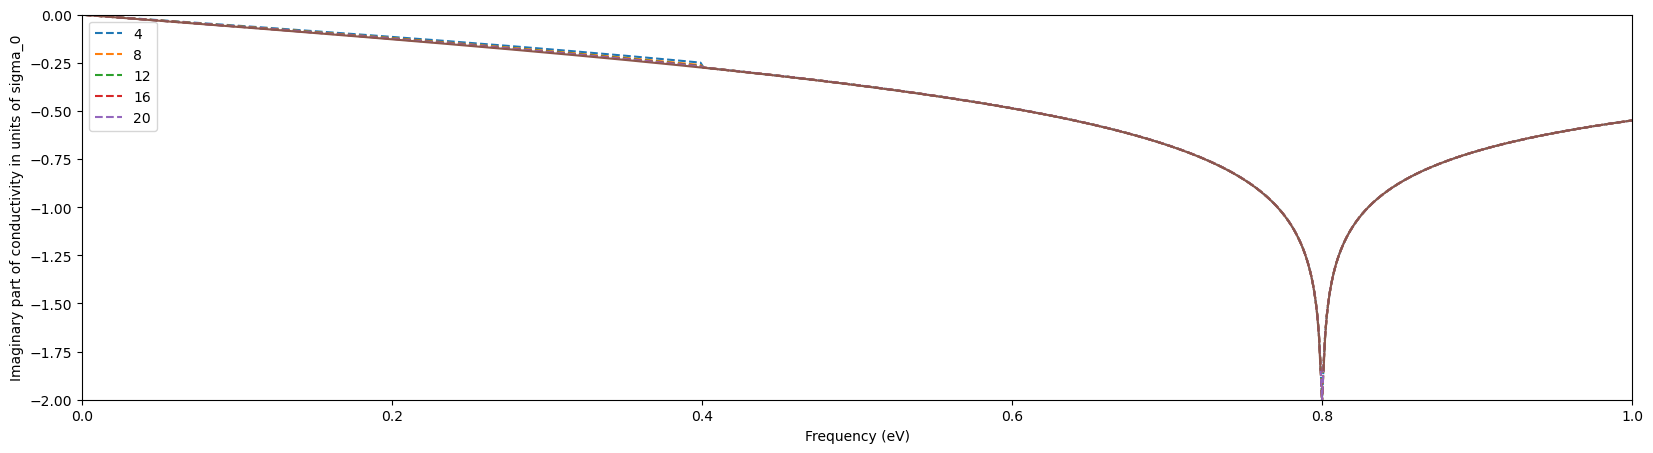

In [241]:
fig, ax = plt.subplots(figsize=(20, 5))
for (n, upper_limit) in enumerate(upper_limits):
    ax.plot(omegas, sigmas[n, :], label=upper_limit, linestyle="dashed")
ax.plot(omegas, sigmas_analytic)
ax.legend()
ax.set_xlabel("Frequency (eV)")
ax.set_ylabel("Imaginary part of conductivity in units of sigma_0")
ax.set_ylim(-2,0);
ax.set_xlim(0, 1);

## Verify that the real part of the integral is negligible (compared to pi/4)
## We do this by changing the imaginary part of omega 

In [265]:
upper_limit = 20
deltas = [0.01, 0.005, 0.001, 0.0005, 0.0001]
real_part_of_integral = zeros((len(deltas), len(omegas)))

for (n, delta) in enumerate(deltas):
    print(f"Evaluating real part of integral with delta: {delta}")
    for (m, omega) in enumerate(omegas):
        omega_tilde = omega + delta*1j
        real_part_of_integral[n, m] = (1j * omega_tilde * quad(lambda x: (H_zero_T(x, epsilon_F) - H_zero_T(omega, epsilon_F))/(omega_tilde**2-4*x**2), 0, upper_limit)[0]).real

Evaluating real part of integral with delta: 0.01
Evaluating real part of integral with delta: 0.005
Evaluating real part of integral with delta: 0.001
Evaluating real part of integral with delta: 0.0005
Evaluating real part of integral with delta: 0.0001


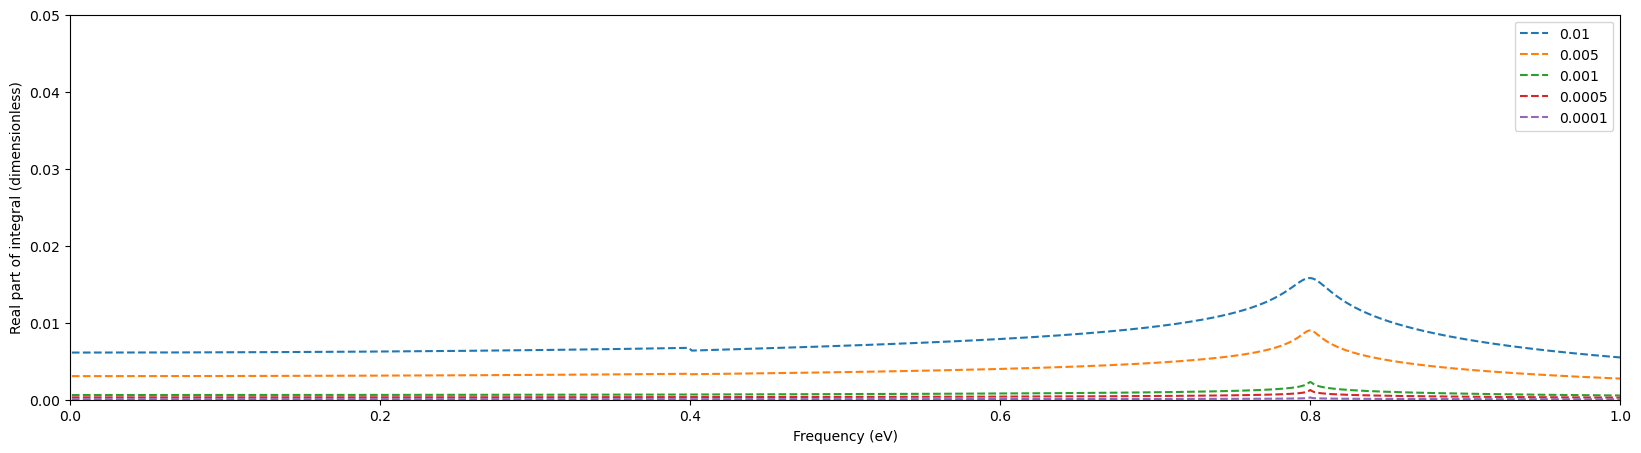

In [272]:
fig, ax = plt.subplots(figsize=(20, 5))
for (n, delta) in enumerate(deltas):
    ax.plot(omegas, real_part_of_integral[n, :], label=delta, linestyle="dashed")
ax.legend()
ax.set_xlabel("Frequency (eV)")
ax.set_ylabel("Real part of integral (dimensionless)")
ax.set_ylim(0,0.05);
ax.set_xlim(0, 1);
